# Flight On-Time Performance
Analysis of about 13,000 flights across 8 routes (March 2023 to August 2024): which routes run late, what drives delays, and how well can delay minutes be predicted. Synthetic dataset built for practice.

## Load the data

In [12]:
import pandas as pd

df = pd.read_csv("../data/flights.csv")
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12989 entries, 0 to 12988
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   flight_id                 12989 non-null  str    
 1   date                      12989 non-null  str    
 2   day_of_week               12989 non-null  str    
 3   origin                    12989 non-null  str    
 4   destination               12989 non-null  str    
 5   route                     12989 non-null  str    
 6   aircraft_id               12989 non-null  str    
 7   aircraft_type             12989 non-null  str    
 8   distance_km               12989 non-null  int64  
 9   scheduled_turnaround_min  12989 non-null  int64  
 10  actual_turnaround_min     12849 non-null  float64
 11  delay_minutes             12989 non-null  float64
 12  weather_event             12989 non-null  int64  
 13  cancelled                 12989 non-null  int64  
 14  load_factor      

flight_id                     0
date                          0
day_of_week                   0
origin                        0
destination                   0
route                         0
aircraft_id                   0
aircraft_type                 0
distance_km                   0
scheduled_turnaround_min      0
actual_turnaround_min       140
delay_minutes                 0
weather_event                 0
cancelled                     0
load_factor                   0
passengers                    0
dtype: int64

## Clean the data
- **35 duplicate `flight_id` rows** are removed.
- **140 missing `actual_turnaround_min` values** are left as they are, because that column is not used in the models.
- On-time performance (OTP) is measured on flights that actually operated, so **cancelled flights are excluded**.

In [13]:
print("Duplicate flight_id rows:", df.duplicated(subset=["flight_id"]).sum())
df_clean = df.drop_duplicates(subset=["flight_id"])
print(f"{len(df)} -> {len(df_clean)} rows")

active = df_clean[df_clean["cancelled"] == 0].copy()
print("Cancelled flights removed:", len(df_clean) - len(active))
print(f"Overall on-time performance: {100 * (active['delay_minutes'] < 15).mean():.1f}%")

Duplicate flight_id rows: 35
12989 -> 12954 rows
Cancelled flights removed: 131
Overall on-time performance: 90.3%


## On-time performance by route
A flight counts as on time if it is less than 15 minutes late.

In [14]:
otp = active.groupby("route")["delay_minutes"].apply(lambda s: 100 * (s < 15).mean())
otp.sort_values()

route
HUB-SPK-C    85.437500
SPK-C-HUB    85.545171
HUB-SPK-A    90.931832
HUB-SPK-B    91.056911
SPK-A-HUB    91.154329
SPK-D-HUB    92.216687
SPK-B-HUB    92.560446
HUB-SPK-D    93.154947
Name: delay_minutes, dtype: float64

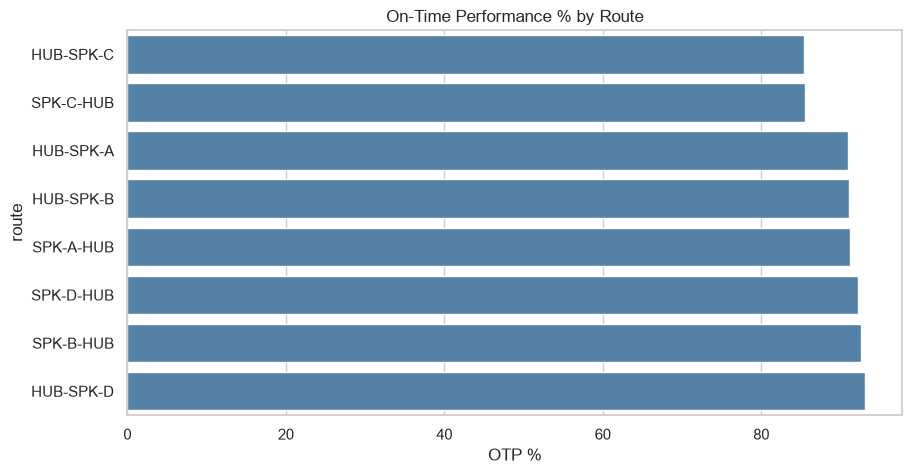

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=otp.sort_values().values, y=otp.sort_values().index, ax=ax, color="steelblue")
ax.set_title("On-Time Performance % by Route")
ax.set_xlabel("OTP %")
plt.show()

## Why are the route C flights slower?
Both directions of route C (HUB-SPK-C and SPK-C-HUB) have the lowest OTP. This table checks whether weather or scheduled turnaround time explains it.

In [16]:
route_check = active.groupby("route").agg(
    flights=("flight_id", "count"),
    avg_delay_min=("delay_minutes", "mean"),
    weather_share_pct=("weather_event", lambda s: 100 * s.mean()),
    avg_scheduled_turnaround_min=("scheduled_turnaround_min", "mean"),
).round(2)
route_check.sort_values("avg_delay_min", ascending=False)

,flights,avg_delay_min,weather_share_pct,avg_scheduled_turnaround_min
route,,,,
SPK-C-HUB,1605,10.43,4.17,36.95
HUB-SPK-C,1600,10.38,4.00,37.03
HUB-SPK-A,1599,8.89,4.07,36.95
SPK-A-HUB,1594,8.75,4.08,36.78
SPK-B-HUB,1613,8.46,4.09,37.04
HUB-SPK-B,1599,8.43,4.07,36.96
SPK-D-HUB,1606,8.01,4.17,37.16
HUB-SPK-D,1607,7.75,4.11,36.98


## Does weather matter?
`weather_event` flags flights affected by a weather event.

In [17]:
weather = active.groupby("weather_event").agg(
    flights=("flight_id", "count"),
    avg_delay_min=("delay_minutes", "mean"),
    otp_pct=("delay_minutes", lambda s: 100 * (s < 15).mean()),
).round(1)
weather

,flights,avg_delay_min,otp_pct
weather_event,,,
0,12298,8.3,92.4
1,525,22.8,40.4


## Predict whether a flight will be delayed (logistic regression)
Delayed means 15 or more minutes late. Features are scaled, so the odds ratios show the effect of a one-standard-deviation change.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

active["delayed"] = (active["delay_minutes"] >= 15).astype(int)

log_features = ["distance_km", "scheduled_turnaround_min", "weather_event"]
X_log = active[log_features]
y_log = active["delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.25, stratify=y_log, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(class_weight="balanced")
logreg.fit(X_train_s, y_train)
proba = logreg.predict_proba(X_test_s)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
odds = pd.Series(np.exp(logreg.coef_[0]), index=log_features)
print(odds.sort_values(ascending=False).round(2))

ROC-AUC: 0.652
weather_event               1.79
scheduled_turnaround_min    1.31
distance_km                 0.87
dtype: float64


## Flag unusual flights (Isolation Forest)
Isolation Forest scores how easy each flight is to isolate. About 2% of flights are flagged as unusual.

In [19]:
from sklearn.ensemble import IsolationForest

iso_features = active[["delay_minutes", "distance_km", "scheduled_turnaround_min"]]
iso = IsolationForest(contamination=0.02, random_state=42)
active["anomaly"] = iso.fit_predict(iso_features)

anomalies = active[active["anomaly"] == -1]
print(f"Flagged {len(anomalies)} unusual flights")
anomalies[["flight_id", "route", "distance_km", "delay_minutes"]].sort_values("delay_minutes", ascending=False).head(10)

Flagged 255 unusual flights


,flight_id,route,distance_km,delay_minutes
6856,FL-0006838,HUB-SPK-B,759,137.0
8132,FL-0008107,SPK-B-HUB,1114,117.3
11755,FL-0011724,SPK-B-HUB,1114,91.9
6887,FL-0006869,HUB-SPK-D,997,91.3
2214,FL-0002209,SPK-C-HUB,1062,90.5
10556,FL-0010527,HUB-SPK-C,700,86.9
821,FL-0000820,SPK-C-HUB,1062,84.1
4013,FL-0004006,SPK-A-HUB,1359,82.2
8123,FL-0008098,HUB-SPK-C,700,77.5
8688,FL-0008662,HUB-SPK-C,700,76.2


## Predict delay minutes: three models compared
All three models use the same features and the same train/test split, so the comparison is fair.

In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

features = ["distance_km", "scheduled_turnaround_min", "weather_event"]
X = active[features]
y = active["delay_minutes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler2 = StandardScaler()
X_train_s, X_test_s = scaler2.fit_transform(X_train), scaler2.transform(X_test)

models = {
    "Random Forest": (RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42), False),
    "Ridge": (Ridge(alpha=5.0), True),
}

rows = []
for name, (model, scaled) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if scaled else (X_train, X_test)
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    rows.append((name, mean_absolute_error(y_test, pred), r2_score(y_test, pred)))

results = pd.DataFrame(rows, columns=["model", "MAE_min", "R2"]).round(3)
print("Baseline MAE if we always predicted the average:", round(mean_absolute_error(y_test, [y_train.mean()] * len(y_test)), 3))
results

Baseline MAE if we always predicted the average: 4.043


,model,MAE_min,R2
0,Random Forest,3.842,0.211
1,Gradient Boosting,3.848,0.209
2,Ridge,3.902,0.189


### What drives delay minutes?
Ridge coefficients on scaled features: minutes of delay added per one-standard-deviation increase.

In [21]:
ridge = models["Ridge"][0]
pd.Series(ridge.coef_, index=features).sort_values(ascending=False).round(2)

weather_event               2.97
scheduled_turnaround_min    0.55
distance_km                -0.19
dtype: float64

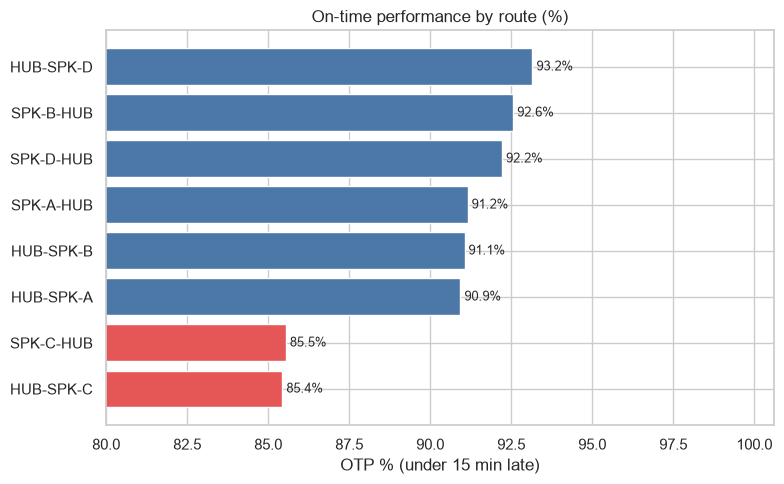

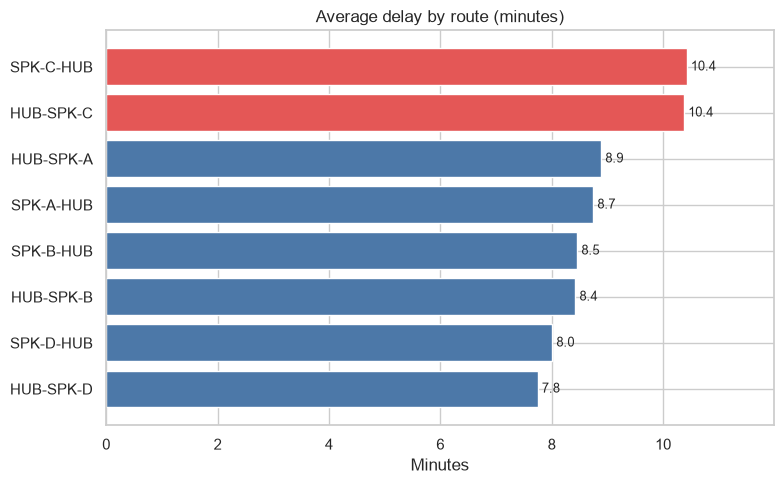

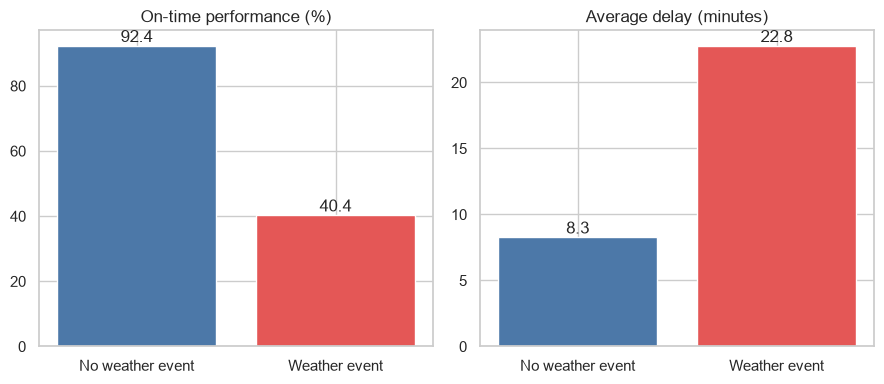

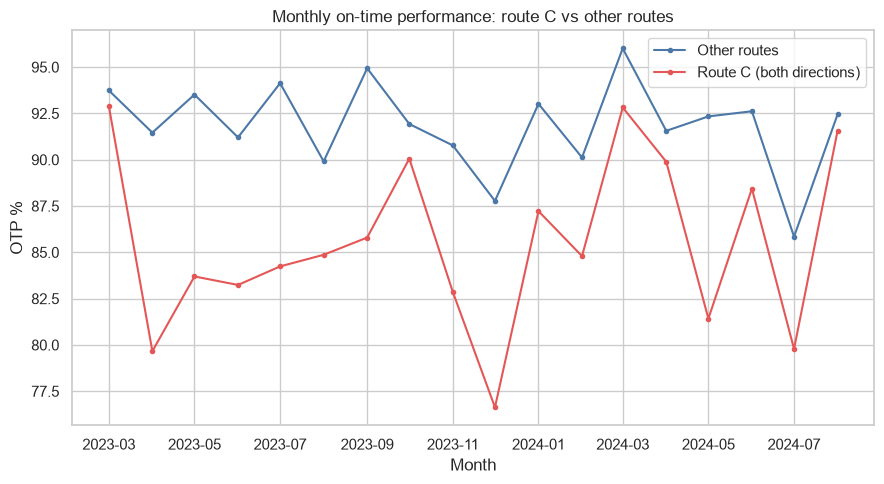

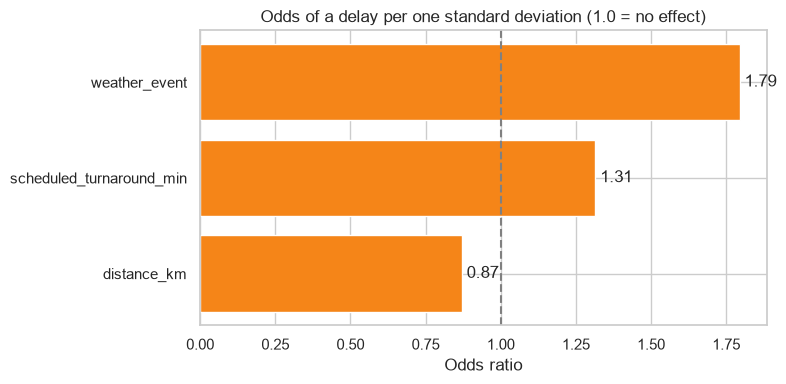

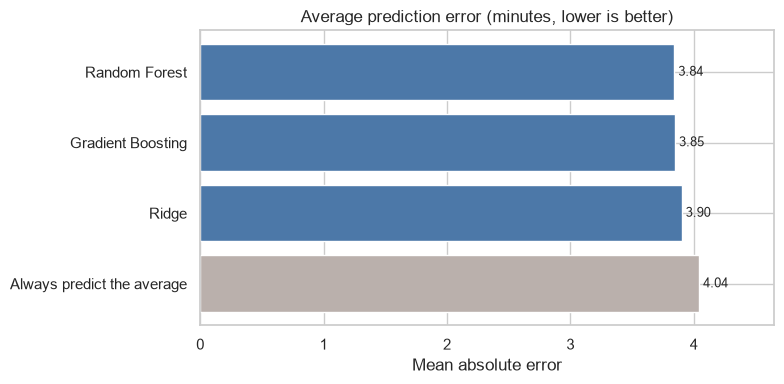

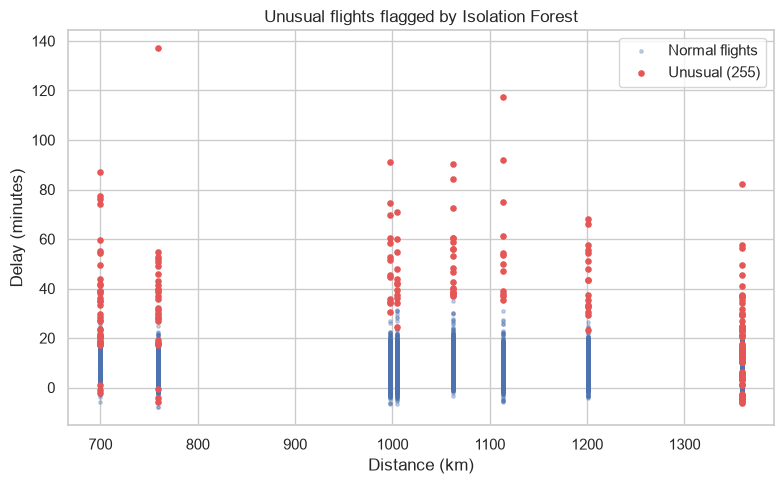

In [22]:
# ---- ONE CELL: creates and saves 7 charts into ../images/ ----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

os.makedirs("../images", exist_ok=True)
flights = pd.read_csv("../data/flights.csv").drop_duplicates(subset=["flight_id"])
flights["date"] = pd.to_datetime(flights["date"])
active = flights[flights["cancelled"] == 0].copy()
active["on_time"] = (active["delay_minutes"] < 15).astype(int)

def save(name):
    plt.tight_layout()
    plt.savefig(f"../images/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def hbar(series, title, xlabel, colors, figsize=(8, 5), fmt="{:.1f}", xmin=0):
    plt.figure(figsize=figsize)
    plt.barh(series.index.astype(str), series.values, color=colors)
    for i, v in enumerate(series.values):
        plt.text(v, i, " " + fmt.format(v), va="center", fontsize=9)
    plt.xlim(xmin, series.max() * 1.08 if xmin else series.max() * 1.15)
    plt.title(title); plt.xlabel(xlabel)

# 1. On-time performance by route
otp = (active.groupby("route")["on_time"].mean() * 100).sort_values()
colors = ["#e45756" if "SPK-C" in r else "#4c78a8" for r in otp.index]
hbar(otp, "On-time performance by route (%)", "OTP % (under 15 min late)", colors, xmin=80, fmt="{:.1f}%")
save("01_otp_by_route")

# 2. Average delay by route
delay = active.groupby("route")["delay_minutes"].mean().sort_values()
colors = ["#e45756" if "SPK-C" in r else "#4c78a8" for r in delay.index]
hbar(delay, "Average delay by route (minutes)", "Minutes", colors)
save("02_avg_delay_by_route")

# 3. Weather impact
w = active.groupby("weather_event").agg(otp=("on_time", lambda s: 100 * s.mean()),
                                        delay=("delay_minutes", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
labels = ["No weather event", "Weather event"]
axes[0].bar(labels, w["otp"], color=["#4c78a8", "#e45756"])
axes[0].set_title("On-time performance (%)")
axes[1].bar(labels, w["delay"], color=["#4c78a8", "#e45756"])
axes[1].set_title("Average delay (minutes)")
for ax, col in zip(axes, ["otp", "delay"]):
    for i, v in enumerate(w[col]):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")
save("03_weather_impact")

# 4. Monthly OTP: route C vs other routes
active["month"] = active["date"].dt.to_period("M").dt.to_timestamp()
active["route_group"] = np.where(active["route"].str.contains("SPK-C"), "Route C (both directions)", "Other routes")
m = active.groupby(["month", "route_group"])["on_time"].mean().unstack() * 100
plt.figure(figsize=(9, 5))
palette = {"Route C (both directions)": "#e45756", "Other routes": "#4c78a8"}
for col in m.columns:
    plt.plot(m.index, m[col], marker="o", markersize=3, label=col, color=palette[col])
plt.title("Monthly on-time performance: route C vs other routes")
plt.xlabel("Month"); plt.ylabel("OTP %"); plt.legend()
save("04_monthly_otp_route_c_vs_rest")

# 5. Logistic regression odds ratios
features = ["distance_km", "scheduled_turnaround_min", "weather_event"]
active["delayed"] = (active["delay_minutes"] >= 15).astype(int)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    active[features], active["delayed"], test_size=0.25, stratify=active["delayed"], random_state=42)
Xs = StandardScaler().fit_transform(Xl_train)
logreg = LogisticRegression(class_weight="balanced").fit(Xs, yl_train)
odds = pd.Series(np.exp(logreg.coef_[0]), index=features).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(odds.index, odds.values, color="#f58518")
plt.axvline(1, color="grey", linestyle="--")
for i, v in enumerate(odds.values):
    plt.text(v, i, f" {v:.2f}", va="center")
plt.title("Odds of a delay per one standard deviation (1.0 = no effect)")
plt.xlabel("Odds ratio")
save("05_delay_odds_ratios")

# 6. Model comparison (average error in minutes)
X, y = active[features], active["delay_minutes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
sc = StandardScaler().fit(X_train)
fits = {
    "Random Forest": (RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42), False),
    "Ridge": (Ridge(alpha=5.0), True),
}
errors = {"Always predict the average": mean_absolute_error(y_test, [y_train.mean()] * len(y_test))}
for name, (model, scaled) in fits.items():
    model.fit(sc.transform(X_train) if scaled else X_train, y_train)
    errors[name] = mean_absolute_error(y_test, model.predict(sc.transform(X_test) if scaled else X_test))
err = pd.Series(errors).sort_values(ascending=False)
hbar(err, "Average prediction error (minutes, lower is better)", "Mean absolute error",
     ["#bab0ac" if "average" in n else "#4c78a8" for n in err.index], figsize=(8, 4), fmt="{:.2f}")
save("06_model_comparison")

# 7. Unusual flights (Isolation Forest)
iso = IsolationForest(contamination=0.02, random_state=42)
active["anomaly"] = iso.fit_predict(active[["delay_minutes", "distance_km", "scheduled_turnaround_min"]])
plt.figure(figsize=(8, 5))
normal = active[active["anomaly"] == 1]; odd = active[active["anomaly"] == -1]
plt.scatter(normal["distance_km"], normal["delay_minutes"], s=6, alpha=0.3, label="Normal flights")
plt.scatter(odd["distance_km"], odd["delay_minutes"], s=14, color="#e45756", label=f"Unusual ({len(odd)})")
plt.title("Unusual flights flagged by Isolation Forest")
plt.xlabel("Distance (km)"); plt.ylabel("Delay (minutes)"); plt.legend()
save("07_unusual_flights")